# Assignment 1.1 — RNN Language Model

This notebook walks through building a complete RNN-based language model pipeline:

1. **Tokenization** — split text, build vocab, wrap into a HuggingFace-compatible tokenizer
2. **Data loading** — load train/val text files, create DataLoaders
3. **Model architecture** — embedding → LSTM → unembedding
4. **Training** — AdamW optimizer, epoch loop, validation
5. **Evaluation** — next-word prediction, perplexity, embedding nearest-neighbors

The training data is Wikipedia text. Expected perplexity after training: **200–300** (lower is better).

In [1]:
import torch, nltk, pickle
from torch import nn
from collections import Counter
from transformers import BatchEncoding, PretrainedConfig, PreTrainedModel, TrainingArguments
from transformers.modeling_outputs import CausalLMOutput
from datasets import load_dataset
from torch.utils.data import DataLoader
import numpy as np
import time
import ssl


try:
    _create_unverified_https_context = ssl._create_unverified_context
except AttributeError:
    pass
else:
    ssl._create_default_https_context = _create_unverified_https_context

nltk.download('punkt', quiet=True)
nltk.download('punkt_tab', quiet=True)

/Users/matheus/dev/phd/dl4nlp/wasp-deep-learning-for-nlp/.venv/lib/python3.14/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


True

---
## Part 1 — Tokenization

Tokenization turns raw text into integer sequences that the model can process.

### Task 1.1 — Word splitting ⚙

We use NLTK's `word_tokenize` to split text into words, then lowercase everything.
Special characters and punctuation become their own tokens.

In [2]:
def lowercase_tokenizer(text):
    return [t.lower() for t in nltk.word_tokenize(text)]

# Quick sanity check
example = "She lives in San Francisco."
print(lowercase_tokenizer(example))

['she', 'lives', 'in', 'san', 'francisco', '.']


### Task 1.2 — Building the vocabulary 🎓

The vocabulary is a `{token → integer}` mapping. We reserve the first four slots for special tokens:

| Index | Token | Purpose |
|-------|-------|---------|
| 0 | `<PAD>` | Padding shorter sequences in a batch |
| 1 | `<UNK>` | Rare / unseen words |
| 2 | `<BOS>` | Beginning-of-paragraph marker |
| 3 | `<EOS>` | End-of-paragraph marker |
| 4 | `the` | ... |

The remaining slots are filled with the most frequent tokens up to `max_voc_size`.

In [3]:
def build_vocab(train_file, tokenize_fun=lowercase_tokenizer, max_voc_size=None,
                pad_token='<PAD>', unk_token='<UNK>', bos_token='<BOS>', eos_token='<EOS>') -> dict:
    """Build a vocabulary from the given file, i.e. a mapping from token strings to integers.

        Token to index.

        Args:
             train_file: The name of the file containing the training texts.
             tokenize_fun: The function to tokenize the text.
             max_voc_size: The maximally allowed size of the vocabulary. If None, then there is no limit.
             pad_token:  The dummy string corresponding to padding.
             unk_token:  The dummy string corresponding to out-of-vocabulary tokens.
             bos_token:  The dummy string corresponding to the beginning of the text.
             eos_token:  The dummy string corresponding to the end the text.
        Returns:
             A dictionary mapping token strings to integers. 
             Example: {'<PAD>': 0, '<UNK>': 1, '<BOS>': 2, '<EOS>': 3, 'the': 4, 'a': 5, ...}
    """
    start_time = time.time()
    vocab = {pad_token: 0, unk_token: 1, bos_token: 2, eos_token: 3}

    with open(train_file, 'r') as f:
        text = f.read()

    # Tokenize the text into a list of tokens.
    tokens = tokenize_fun(text)

    # Count the frequency of each token
    counter = Counter(tokens)

    # Print some statistics about the token frequencies.
    print(f'Total tokens: {len(tokens):,}')
    print(f'Unique tokens: {len(counter):,}')
    print(f'Top 10: {counter.most_common(10)}')

    # Inspect how rare the last words in the vocab are. To judge if max_voc_size is large enough.
    if max_voc_size is not None:
        print(f'Last words at cutoff: {counter.most_common(max_voc_size)[-20:]}')

    # Make a plot where in the x-axis we have tokens sorted by frequency and y-axis the frequency.
    # import matplotlib.pyplot as plt
    # plt.figure(figsize=(10, 5))
    # plt.plot(np.arange(max_voc_size), [freq for _, freq in counter.most_common(max_voc_size)])
    # plt.yscale('log')
    # plt.xlabel('Tokens sorted by frequency')
    # plt.ylabel('Frequency (log scale)')
    # plt.title('Token frequency distribution')
    # plt.show()

    # Add the most common tokens to the vocabulary, up to max_voc_size if specified.
    for token, _ in counter.most_common(max_voc_size):
        if len(vocab) == max_voc_size:
            break
        vocab[token] = len(vocab) # append to the end

    print(f'Vocabulary built in {time.time() - start_time:.2f}s. Size: {len(vocab):,}.')
    return vocab


def get_i2t(vocab):
    """Invert the vocab dict: int -> token."""
    return {v: k for k, v in vocab.items()}


def get_token_id(vocab: dict, token: str, unk_token: str = '<UNK>') -> int:
    """Return the integer for a token, falling back to <UNK> if unseen."""
    return vocab.get(token, vocab[unk_token])

In [4]:
def test_build_vocab():
    vocab = build_vocab('train.txt', max_voc_size=1000)
    i2t = get_i2t(vocab)
    assert i2t[0] == '<PAD>'
    assert i2t[1] == '<UNK>'
    assert i2t[2] == '<BOS>'
    assert i2t[3] == '<EOS>'
    # Check they don't clash with real words
    real_words = {k: v for k, v in vocab.items() if k not in ['<PAD>', '<UNK>', '<BOS>', '<EOS>']}
    assert len(real_words) == len(vocab) - 4
    assert len(vocab) <= 1000
    assert 'the' in vocab
    assert 'a' in vocab
    assert 'cuboidal' not in vocab
    assert 'epiglottis' not in vocab
    print('build_vocab test passed.')

test_build_vocab()

Total tokens: 12,046,329
Unique tokens: 250,574
Top 10: [('the', 772802), (',', 635406), ('.', 445279), ('of', 393879), ('and', 307502), ('in', 278314), ('to', 231143), ('a', 216080), ("''", 154426), ('``', 145205)]
Last words at cutoff: [('report', 1195), ('sun', 1194), ('potential', 1193), ('russian', 1193), ('?', 1192), ('noted', 1192), ('go', 1192), ('ad', 1192), ('loss', 1191), ('element', 1189), ('object', 1189), ('finally', 1189), ('applied', 1187), ('italian', 1187), ('married', 1186), ('carried', 1183), ('training', 1182), ('intended', 1182), ('brother', 1180), ('ireland', 1180)]
Vocabulary built in 33.85s. Size: 1,000.
build_vocab test passed.


Here, we see that vocab size 1000 is small, since common words such as sun, report, potential ended up outside of the vocab.

### Task 1.3 — HuggingFace-compatible tokenizer ⚙

`A1Tokenizer` wraps the vocabulary into an object that mirrors the HuggingFace API:
- `__call__` converts a list of strings to a `BatchEncoding` with `input_ids` and `attention_mask`
- `__len__` returns vocabulary size
- `save` / `from_file` allow persisting the tokenizer to disk

The attention mask is **1** for real tokens and **0** for padding.

In [5]:
class A1Tokenizer:
    """Minimal HuggingFace-like tokenizer."""

    def __init__(self, vocab, model_max_length=None,
                 pad_token='<PAD>', unk_token='<UNK>', bos_token='<BOS>', eos_token='<EOS>'):
        self.vocab = vocab
        self.pad_token_id = vocab[pad_token]
        self.unk_token_id = vocab[unk_token]
        self.bos_token_id = vocab[bos_token]
        self.eos_token_id = vocab[eos_token]
        self.model_max_length = model_max_length

    def __call__(self, texts, truncation=False, padding=False, return_tensors=None):
        """Tokenize the given texts and return a BatchEncoding containing the integer-encoded tokens.
           
           Args:
             texts:           The texts to tokenize.
             truncation:      Whether the texts should be truncated to model_max_length.
             padding:         Whether the tokenized texts should be padded on the right side.
             return_tensors:  If None, then return lists; if 'pt', then return PyTorch tensors.

           Returns:
             A BatchEncoding where the field `input_ids` stores the integer-encoded texts,
             and `attention_mask` stores a mask indicating which tokens are real and which are paddings.

        """
        if return_tensors and return_tensors != 'pt':
            raise ValueError('return_tensors must be "pt" or None')
        
        # Accept either a single string or a list of strings.
        if isinstance(texts, str):
            texts = [texts]
        elif not isinstance(texts, list) or not all(isinstance(t, str) for t in texts):
            raise TypeError('texts must be a string or list of strings')

        # Split the texts into words and map them to integer values.
        max_length = 0
        list_of_ids = []
        for text in texts:

            # str -> list[str]
            tokens = lowercase_tokenizer(text) # "the book is on the table" -> ["the", "book", "is", ...]

            # list[str] -> list[int]
            ids = [self.bos_token_id] + \
                  [get_token_id(self.vocab, token) for token in tokens] + \
                  [self.eos_token_id]
            
            max_length = max(max_length, len(ids)) # Keep track of the longest sequence, to know how much to pad.
            list_of_ids.append(ids)

        # Apply truncation and padding if specified.
        for i, ids in enumerate(list_of_ids):
            if padding and len(ids) < max_length:
                # Pad all sequences to the length of the longest sequence in the batch.
                list_of_ids[i] = ids + (max_length - len(ids)) * [self.pad_token_id]
            if truncation:
                list_of_ids[i] = list_of_ids[i][:self.model_max_length]

        # Option: to be 100% HuggingFace compatible, we return an attention mask of the same shape
        # as list_of_ids. This describes which tokens are real and which are padding tokens.
        attention_mask = [[0 if id_ == self.pad_token_id else 1 for id_ in ids]
                          for ids in list_of_ids]

        if return_tensors == 'pt':
            list_of_ids = torch.tensor(list_of_ids, dtype=torch.long)
            attention_mask = torch.tensor(attention_mask)

        return BatchEncoding({'input_ids': list_of_ids, 'attention_mask': attention_mask})

    def __len__(self):
        return len(self.vocab)

    def decode(self, token_ids, skip_special_tokens=True):
        i2t = get_i2t(self.vocab)
        special_ids = {self.pad_token_id, self.unk_token_id, self.bos_token_id, self.eos_token_id}
        tokens = []
        for id_ in token_ids:
            if isinstance(id_, torch.Tensor):
                id_ = id_.item()
            if skip_special_tokens and id_ in special_ids:
                continue
            tokens.append(i2t.get(id_, '<UNK>'))
        return ' '.join(tokens)

    def save(self, filename):
        """Save the tokenizer to the given file."""
        with open(filename, 'wb') as f:
            pickle.dump(self, f)

    @staticmethod
    def from_file(filename):
        """Load a tokenizer from the given file."""
        with open(filename, 'rb') as f:
            return pickle.load(f)


def build_tokenizer(train_file, tokenize_fun=lowercase_tokenizer, max_voc_size=None,
                    model_max_length=None, pad_token='<PAD>', unk_token='<UNK>',
                    bos_token='<BOS>', eos_token='<EOS>'):
    vocab = build_vocab(train_file, tokenize_fun, max_voc_size, pad_token, unk_token, bos_token, eos_token)
    return A1Tokenizer(vocab, model_max_length, pad_token, unk_token, bos_token, eos_token)


def load_tokenizer():
    tokenizer = A1Tokenizer.from_file('tokenizer.tok')
    print(f'Tokenizer loaded. Vocabulary size: {len(tokenizer):,}.')
    return tokenizer

In [6]:
# Build and save the tokenizer (run once; reload afterwards)
if False: # Skip this step 
    tokenizer = build_tokenizer('train.txt', max_voc_size=10000, model_max_length=256)
    tokenizer.save('tokenizer.tok')
    print('Tokenizer saved.')

In [7]:
# Load from disk and test
tokenizer = load_tokenizer()

test_texts = ['This is a test.', 'Another test.']
result = tokenizer(test_texts, return_tensors='pt', padding=True, truncation=True)
print('input_ids shape:', result.input_ids.shape)
print(result)

# {'input_ids': tensor([[  2,  35,  14,  11, 975,   6,   3],
#                       [  2, 155, 975,   6,   3,   0,   0]]), 
#  'attention_mask': tensor([[1, 1, 1, 1, 1, 1, 1],
#                            [1, 1, 1, 1, 1, 0, 0]])}

Tokenizer loaded. Vocabulary size: 10,000.
input_ids shape: torch.Size([2, 7])
{'input_ids': tensor([[  2,  35,  14,  11, 975,   6,   3],
        [  2, 155, 975,   6,   3,   0,   0]]), 'attention_mask': tensor([[1, 1, 1, 1, 1, 1, 1],
        [1, 1, 1, 1, 1, 0, 0]])}


---
## Part 2 — Data Loading and Batching

### Task 2.1 — Loading texts ⚙

We use HuggingFace `datasets` to load the raw text files. Empty lines are filtered out.
Expected sizes: ~147k training paragraphs, ~18k validation paragraphs.

In [8]:
def get_dataset(data_files={'train': 'train.txt', 'val': 'val.txt'}, use_subset=False):
    from torch.utils.data import Subset

    dataset = load_dataset('text', data_files=data_files)
    print(f"Train instances: {len(dataset['train']):,}")
    print(f"Validation instances: {len(dataset['val']):,}")

    # Remove empty lines
    dataset = dataset.filter(lambda x: x['text'].strip() != '')

    # Use subset for training purposes:
    if use_subset:
        for sec in ['train', 'val']:
            dataset[sec] = Subset(dataset[sec], range(1000))
            print(f"{sec} instances after subset: {len(dataset[sec])}")

    return dataset

dataset = get_dataset()

# TODO: optional task
# Optional task: If you want to be even more closely aligned with the HuggingFace standard API, you should also 
# 1) use tokenized texts in the Datasets instead of raw text, and 
# 2) apply a collator, such as DataCollatorForLanguageModeling.

Train instances: 294,118
Validation instances: 35,748


### Task 2.2 — Creating batches ⚙

PyTorch `DataLoader` handles shuffling, batching, and multi-process prefetching.
Tokenization is applied lazily inside the training loop rather than upfront, so raw text is stored in the dataset.

In [9]:
# Quick preview of what a batch looks like before tokenization
preview_loader = DataLoader(dataset['train'], batch_size=4, shuffle=True)
sample_batch = next(iter(preview_loader))
for t in sample_batch['text']:
    print(repr(t[:80]))

'A candidate pilot is likely to study for a qualification in aeronautical science'
'Video game development and authorship, much like any other form of entertainment'
'The didactic cinquain is closely related to the Crapsey cinquain.  It is an info'
"Wigner's family was Jewish, but not religiously observant, and his Bar Mitzvah w"


---
## Part 3 — Neural Network Architecture

### Task 3.1 — Network setup 🎓

The model has three layers:

```
input_ids (B, N)  →  Embedding (B, N, E)  →  LSTM (B, N, H)  →  Linear (B, N, V)
```

- **B** = batch size, **N** = sequence length
- **E** = embedding size, **H** = hidden size, **V** = vocabulary size

We inherit from `PreTrainedModel` so we get `save_pretrained` / `from_pretrained` for free.
Hyperparameters live in a `PretrainedConfig` subclass.

In [10]:
class A1RNNModelConfig(PretrainedConfig):
    """Configuration object that stores hyperparameters that define the RNN-based language model."""
    def __init__(self, vocab_size=0, embedding_size=0, hidden_size=0, **kwargs):
        super().__init__(**kwargs)
        self.vocab_size = vocab_size
        self.hidden_size = hidden_size
        self.embedding_size = embedding_size

### Task 3.2 — Loss computation 🎓

Language modeling is a next-token prediction task: given token $t_i$, predict $t_{i+1}$.

We therefore **shift** logits and labels by one position before computing cross-entropy:

```
input:        [<BOS>,  She,  lives,  in,  San,  <EOS>]
shift_logits: [<BOS>,  She,  lives,  in,  San ]   ← drop last logit
shift_labels: [  She,  lives,  in,  San,  <EOS>]  ← drop first label
```

Padding tokens get label `-100` so `CrossEntropyLoss` ignores them (`ignore_index=-100`).

Comments about the code:
- `contiguous()` makes sure the tensor is stored contiguously in memory, which is required for the loss function

In [11]:
class A1RNNModel(PreTrainedModel):
    """LSTM-based language model."""
    config_class = A1RNNModelConfig
    _tied_weights_keys = []
    all_tied_weights_keys = {}

    def __init__(self, config):
        super().__init__(config)
        self.embedding   = nn.Embedding(config.vocab_size, config.embedding_size)
        self.rnn         = nn.LSTM(config.embedding_size, config.hidden_size, batch_first=True) # batch_first: B, N, E (batch, sequence length, embedding size)
        self.unembedding = nn.Linear(config.hidden_size, config.vocab_size) # An output layer (aka unembedding layer) that computes the (logits of) a probability distribution over the vocaulary
        self.loss_func   = nn.CrossEntropyLoss(ignore_index=-100) # Note: -100 is the value HuggingFace conventionally uses to refer to tokens where we do not want to compute the loss.

    def forward(self, input_ids, labels=None):
        """The forward pass of the RNN-based language model.
        
           Args:
             - input_ids:  The input tensor (2D), consisting of a batch of integer-encoded texts.     (B, N)
             - labels:     The reference tensor (2D), consisting of a batch of integer-encoded texts. (B, N)
           Returns:
             A CausalLMOutput containing
               - logits:   The output tensor (3D), consisting of logits for all token positions for all vocabulary items.
               - loss:     The loss computed on this batch.               
        """
        embedded = self.embedding(input_ids)       # (B, N, E)
        rnn_out, _ = self.rnn(embedded)            # (B, N, H), hidden = hidden size
        logits = self.unembedding(rnn_out)         # (B, N, V), V = vocab size

        loss = None
        if labels is not None:
            shift_logits = logits[:, :-1, :].contiguous()   # drop last position, since we don't care about predicting the token after the end of the text
            shift_labels = labels[:, 1:].contiguous()       # drop first position, since we don't care about predicting the beginning of the text

            # Dummy example: input = "hello friend" -> input_ids = [0, 459, 789, 1], where 0 is <BOS> and 1 is <EOS>. labels = input_ids since we want to predict the same text 
            # Then: logits = [logits(0), logits(459), logits(789), logits(1)]
            # shift_logits = [logits(0), logits(459), logits(789)] --> we don't care about the logits(1) since there is no next token after <EOS>.
            #       labels = [0, 459, 789, 1]
            # shift_labels = [459, 789, 1]   --> we don't care about the loss for the first token 0, since there is no word before <BOS>.
            # That is, we compare:
            # logits(0) -> 459 (<BOS> -> hello)
            # logits(459) -> 789 (hello -> friend)
            # logits(789) -> 1 (friend -> <EOS>)
            
            # 
            # Reshape logits and labels to compute the loss:
            shift_labels = shift_labels.view(-1)           # reshape the labels from (B, N) to (B*N,)
            shift_logits = shift_logits.view(-1, self.config.vocab_size) # reshape the logits from (B, N, V) to (B*N, V)
            loss = self.loss_func(shift_logits, shift_labels)

        # Return original (unshifted) logits for inference
        # We'd lose the 1-1 match between input tokens and logits if we returned the shifted logits.
        return CausalLMOutput(logits=logits, loss=loss)

#### **Note on how reshape works to prepare for loss function where `B=2`, `N=3`, `V=4`:**

**Before reshape** — `logits` shape: `(batch_size, seq_len, vocab_size)`
```
logits = [
  [ [0.1, 0.2, 0.3, 0.4],   # hey   → scores for each vocab token as next token
    [0.5, 0.6, 0.7, 0.8],   # my
    [0.9, 1.0, 1.1, 1.2] ], # friend    → batch 1

  [ [0.1, 0.2, 0.3, 0.4],   # what
    [0.5, 0.6, 0.7, 0.8],   # is
    [0.9, 1.0, 1.1, 1.2] ]  # that      → batch 2
]
```

**After reshape** — `logits` shape: `(batch_size * seq_len, vocab_size)`
```
logits = [
  [0.1, 0.2, 0.3, 0.4],   # hey
  [0.5, 0.6, 0.7, 0.8],   # my
  [0.9, 1.0, 1.1, 1.2],   # friend
  [0.1, 0.2, 0.3, 0.4],   # what
  [0.5, 0.6, 0.7, 0.8],   # is
  [0.9, 1.0, 1.1, 1.2],   # that
]
```

**Labels** — before: `(batch_size, seq_len)`, after reshape: `(batch_size * seq_len,)`
```
# Before
labels = [
  [245, 789,   1],   # true next tokens after "hey",  "my",  "friend"
  [345,  39, 131]    # true next tokens after "what", "is",  "that"
]

# After reshape
labels = [245, 789, 1, 345, 39, 131]
```

In [ ]:
def test_model():
    "Test the model on dummy data to check that the forward pass works and the loss is computed without errors."
    tokenizer = load_tokenizer()
    config = A1RNNModelConfig(vocab_size=len(tokenizer), embedding_size=16, hidden_size=32)
    model = A1RNNModel(config)

    input_ids = torch.tensor([[2, 4, 5, 6, 3], [211, 41, 53, 61, 33]])  # B=2, N=5
    # input_ids = torch.tensor([[2, 4, 5, 6, 3]])  # B=1, N=5
    output = model(input_ids) # should be (B, N, V) = (2, 5, vocab_size) for the logits
    print('logits shape:', output.logits.shape)  # expected (2, 5, vocab_size)

    # With labels
    output_with_loss = model(input_ids, labels=input_ids)
    print('loss:', output_with_loss.loss.item())

test_model()

Tokenizer loaded. Vocabulary size: 10,000.
logits shape: torch.Size([2, 5, 10000])
loss: 9.21135425567627


---
## Part 4 — Training

### Task 4.1 — Trainer implementation 🎓

`A1Trainer` mirrors the HuggingFace `Trainer` interface. The training loop:

1. Tokenize each batch on the fly (with padding & truncation)
2. Set padding positions to label `-100`
3. Forward pass → compute loss → backward pass → optimizer step
4. After each epoch, evaluate on the validation set (no gradient updates)

Training is GPU-accelerated when CUDA or MPS is available.

In [20]:
class A1Trainer:
    """A minimal implementation similar to a Trainer from the HuggingFace library."""

    def __init__(self, model, args, train_dataset, eval_dataset, tokenizer):
        """Set up the trainer.
           
           Args:
             model:          The model to train.
             args:           The training parameters stored in a TrainingArguments object.
             train_dataset:  The dataset containing the training documents.
             eval_dataset:   The dataset containing the validation documents.
             tokenizer:      The tokenizer.
        """
        self.model        = model
        self.args         = args
        self.train_dataset = train_dataset
        self.eval_dataset  = eval_dataset
        self.tokenizer    = tokenizer
        assert args.optim == 'adamw_torch'
        assert args.eval_strategy == 'epoch'

    def select_device(self):
        """Return the device to use for training, depending on the training arguments and the available backends."""
        if self.args.use_cpu:
            return torch.device('cpu')
        if torch.cuda.is_available():
            return torch.device('cuda')
        if torch.mps.is_available():
            return torch.device('mps')
        return torch.device('cpu')

    def train(self):
        """Train the model."""
        args   = self.args
        device = self.select_device()
        print('Device:', device)
        self.model.to(device)

        optimizer    = torch.optim.AdamW(self.model.parameters(), lr=args.learning_rate)
        train_loader = DataLoader(self.train_dataset, 
                                  batch_size=args.per_device_train_batch_size, # as large as the GPU allows
                                  num_workers=4, 
                                  pin_memory=True, 
                                  shuffle=True)
        val_loader   = DataLoader(self.eval_dataset,  
                                  batch_size=args.per_device_eval_batch_size,
                                  num_workers=4, 
                                  pin_memory=True, 
                                  shuffle=False)
        
        # Training loop

        for epoch in range(args.num_train_epochs):
            print(f'\nEpoch {epoch+1}/{args.num_train_epochs}')
            self.model.train()
            train_loss = 0.0
            t0 = time.time()

            for batch in train_loader:
                # Apply tokenizer to the batch
                enc    = self.tokenizer(batch['text'], return_tensors='pt', padding=True, truncation=True)
                labels = enc.input_ids.clone()
                labels[enc.attention_mask == 0] = -100 # Set the padding tokens to label -100

                # Put the tensors on the correct device
                enc    = enc.to(device)
                labels = labels.to(device)

                # Forward pass
                output = self.model(enc.input_ids, labels)
                optimizer.zero_grad()

                # Model update
                output.loss.backward()
                optimizer.step()
                train_loss += output.loss.item()

            train_loss /= len(train_loader)
            t1 = time.time()
            print(f'  Train loss: {train_loss:.4f}  ({(t1-t0)/60:.1f} min)')

            torch.cuda.empty_cache()

            # After each epocj, evaluate the model on the validation set
            self.model.eval()
            val_loss = 0.0
            with torch.no_grad():
                for batch in val_loader:
                    enc    = self.tokenizer(batch['text'], return_tensors='pt', padding=True, truncation=True)
                    labels = enc.input_ids.clone()
                    labels[enc.attention_mask == 0] = -100
                    enc    = enc.to(device)
                    labels = labels.to(device)
                    output = self.model(enc.input_ids, labels)
                    val_loss += output.loss.item()
            val_loss /= len(val_loader)
            print(f'  Val   loss: {val_loss:.4f}  ({(time.time()-t1)/60:.1f} min)')

        print(f'\nSaving model to {args.output_dir}')
        self.model.save_pretrained(args.output_dir)

In [ ]:
# --- Configure and run training ---
# Tip: set use_subset=True for a quick smoke-test before committing to a full run.

tokenizer = load_tokenizer()
tokenizer.model_max_length = 256

config = A1RNNModelConfig(vocab_size=len(tokenizer), embedding_size=128, hidden_size=512)
model  = A1RNNModel(config)

training_args = TrainingArguments(
    optim='adamw_torch',
    use_cpu=False,
    eval_strategy='epoch',
    output_dir='trained_output',
    num_train_epochs=2,
    per_device_train_batch_size=256,
    per_device_eval_batch_size=256,
    learning_rate=0.001,
)

dataset = get_dataset(use_subset=True)
trainer = A1Trainer(model, training_args, dataset['train'], dataset['val'], tokenizer)
trainer.train()

---
## Part 5 — Evaluation and Analysis

### Task 5.1 — Next-word prediction ⚙

Given a partial sentence, the model produces a logit vector at the **last real token position**.
Taking the `argmax` gives the single most likely continuation; `topk` gives the top-k candidates.

In [22]:
model = A1RNNModel.from_pretrained('trained_output')
tokenizer = load_tokenizer()
tokenizer.model_max_length = 256
model.eval()
print('Model loaded.')

Loading weights: 100%|██████████| 7/7 [00:00<00:00, 14520.34it/s]

Tokenizer loaded. Vocabulary size: 10,000.
Model loaded.


In [23]:
text = "She lives in San"
input_ids = tokenizer(text, return_tensors='pt').input_ids
print('Input IDs:', input_ids)

with torch.no_grad():
    output = model(input_ids)

# Logits at every position; we care about the last *real* token (index -2, before <EOS>)
last_logits = output.logits[0, -2, :]  # shape (V,)
i2t = get_i2t(tokenizer.vocab)

top5 = torch.topk(last_logits, 5)
print('\nTop-5 predicted next words:')
for score, idx in zip(top5.values, top5.indices):
    print(f'  {i2t[idx.item()]:<20} score={score.item():.3f}')

Input IDs: tensor([[   2,  156, 1898,    9, 1063,    3]])

Top-5 predicted next words:
  francisco            score=9.820
  <UNK>                score=9.729
  diego                score=9.152
  suu                  score=8.358
  antonio              score=7.848


In [24]:
# Use argmax to get the most likely next token for each position in the input text.
predicted_token_ids = torch.argmax(output.logits, dim=-1) # (B, N)
print('Predicted token IDs:', predicted_token_ids)
# Convert the predicted token IDs back to strings using the tokenizer's vocabulary.
i2t = get_i2t(tokenizer.vocab)
predicted_tokens = [[i2t[token_id.item()] for token_id in batch] for batch in predicted_token_ids]
print('Predicted tokens:', predicted_tokens)

Predicted token IDs: tensor([[   4,   18,    9,    4, 2452,    5]])
Predicted tokens: [['the', 'was', 'in', 'the', 'francisco', ',']]


That is, the model predicts next-token for each position:

| Input token | Predicted next |
|-------------|----------------|
| `<BOS>`     | the          |
| She      | was          |
| lives     | in           |
| in        | the          |
| San       | francisco    |
| `<EOS>`     | ,           |

### Task 5.2 — Perplexity 🎓

**Perplexity** measures how surprised the model is by the validation text:

$$\text{PPL} = \exp\!\left(\frac{1}{|\text{val}|}\sum_{\text{batch}} \mathcal{L}_{\text{batch}}\right)$$

A well-trained model should reach **200–300**. Above 700 usually indicates something is wrong.

Perplexity is the exponentiated average loss per token. Common metric for language modeling.

In [26]:
device = torch.device('cuda' if torch.cuda.is_available() else
                       'mps'  if torch.mps.is_available()  else 'cpu')

# Load model
model.to(device)
model.eval()

# Load validation set
dataset   = get_dataset(use_subset=True)
val_loader = DataLoader(dataset['val'], batch_size=256, num_workers=4, pin_memory=True, shuffle=False)

total_loss = 0.0
with torch.no_grad():
    for batch in val_loader:
        enc    = tokenizer(batch['text'], return_tensors='pt', padding=True, truncation=True)
        labels = enc.input_ids.clone()
        labels[enc.attention_mask == 0] = -100
        enc    = enc.to(device)
        labels = labels.to(device)
        output = model(enc.input_ids, labels)
        total_loss += output.loss.item()

mean_loss  = total_loss / len(val_loader)
perplexity = torch.exp(torch.tensor(mean_loss)).item()
print(f'Validation loss: {mean_loss:.4f}')
print(f'Perplexity:      {perplexity:.2f}')

Train instances: 294,118
Validation instances: 35,748
train instances after subset: 1000
val instances after subset: 1000


/Users/matheus/dev/phd/dl4nlp/wasp-deep-learning-for-nlp/.venv/lib/python3.14/site-packages/torch/utils/data/dataloader.py:1118: UserWarning: 'pin_memory' argument is set as true but not supported on MPS now, device pinned memory won't be used.
  super().__init__(loader)


Validation loss: 4.0965
Perplexity:      60.13


### Task 5.3 — Embedding nearest-neighbors 🎓

Word embeddings encode semantic similarity as **cosine similarity** in vector space.
Semantically related words should cluster together after training.

We also visualize a selection of words with **PCA** projected to 2D.

In [28]:
def nearest_neighbors(emb, voc, inv_voc, word, n=5):
    test_emb = emb.weight[voc[word]]
    sim_func = nn.CosineSimilarity(dim=1)
    scores   = sim_func(test_emb, emb.weight)
    topk     = scores.topk(n + 1)  # +1 because the word itself is always #1
    return [(inv_voc[idx.item()], f'{cos.item():.3f}')
            for idx, cos in zip(topk.indices[1:], topk.values[1:])]


emb     = model.embedding.cpu()
voc     = tokenizer.vocab
inv_voc = get_i2t(voc)

# Test the nearest neighbor function on some words
for word in ['sweden', 'king', 'computer', 'war']:
    if word in voc:
        print(f'{word:15} → {nearest_neighbors(emb, voc, inv_voc, word)}')
    else:
        print(f'{word} not in vocabulary')

sweden          → [('netherlands', '0.375'), ('croatia', '0.365'), ('ba', '0.364'), ('esa', '0.351'), ('programmer', '0.346')]
king            → [('father', '0.396'), ('hope', '0.349'), ('owner', '0.343'), ('relatives', '0.341'), ('supporter', '0.320')]
computer        → [('solutions', '0.335'), ('assault', '0.314'), ('audio', '0.311'), ('galaxies', '0.306'), ('jupiter', '0.305')]
war             → [('auschwitz', '0.366'), ('stress', '0.313'), ('constantine', '0.308'), ('barracks', '0.302'), ('afghanistan', '0.295')]


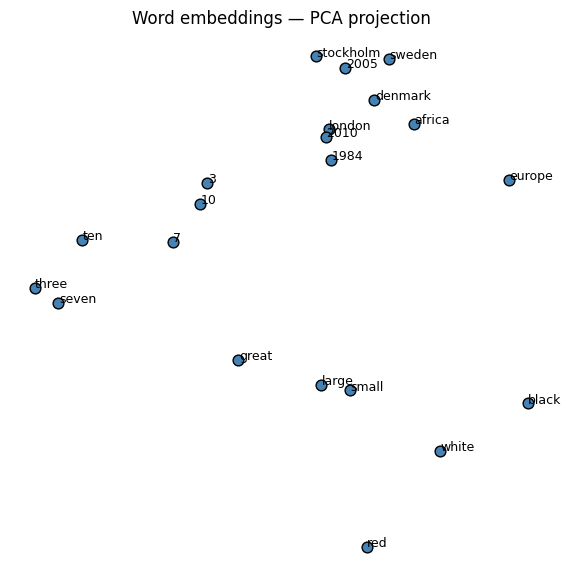

Saved embeddings_pca.png


In [29]:
def plot_embeddings_pca(emb, voc, inv_voc, words):
    """Plot word embeddings projected to 2D via truncated SVD (PCA-equivalent)."""
    from sklearn.decomposition import TruncatedSVD
    import matplotlib.pyplot as plt

    words   = [w for w in words if w in voc]
    vectors = np.vstack([emb.weight[voc[w]].detach().numpy() for w in words])
    vectors -= vectors.mean(axis=0)
    twodim  = TruncatedSVD(n_components=2).fit_transform(vectors)

    plt.figure(figsize=(7, 7))
    plt.scatter(twodim[:, 0], twodim[:, 1], edgecolors='k', c='steelblue', s=60)
    for word, (x, y) in zip(words, twodim):
        plt.text(x + 0.01, y, word, fontsize=9)
    plt.axis('off')
    plt.title('Word embeddings — PCA projection')
    plt.savefig('embeddings_pca.png', dpi=150, bbox_inches='tight')
    plt.show()
    print('Saved embeddings_pca.png')


words_to_plot = [
    'sweden', 'denmark', 'europe', 'africa', 'london', 'stockholm',
    'large', 'small', 'great',
    'black', 'white', 'red',
    '3', '7', '10', 'seven', 'three', 'ten',
    '1984', '2005', '2010'
]
plot_embeddings_pca(emb, voc, inv_voc, words_to_plot)

Result: quite clear separate clusters of countries, numbers, and colors.